In [1]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"paprichat","key":"2b7bb4043d2c113496df6a0a81098915"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!pip install kaggle


In [4]:
!kaggle datasets list


ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
rakeshkapilavai/extrovert-vs-introvert-behavior-data            Extrovert vs. Introvert Behavior Data                   31277  2025-06-13 14:26:48.303000          17532        386  1.0              
bismasajjad/global-ai-job-market-and-salary-trends-2025         Global AI Job Market & Salary Trends 2025              529004  2025-06-01 07:20:49.537000           5962         97  0.9411765        
adilshamim8/social-media-addiction-vs-relationships             Students' Social Media Addiction                         7851  2025-05-10 14:38:02.713000          16740        254  1.0              
thero

In [7]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the dataset
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.28G/2.29G [00:18<00:00, 216MB/s]
100% 2.29G/2.29G [00:18<00:00, 130MB/s]


In [43]:
import os

base_dir = "chest_xray"

for split in ["train", "val", "test"]:
    path = os.path.join(base_dir, split)
    print(f"\n {split.upper()} contains folders: {os.listdir(path)}")

    for category in os.listdir(path):
        class_path = os.path.join(path, category)
        print(f"- {category} has {len(os.listdir(class_path))} images")



 TRAIN contains folders: ['PNEUMONIA', 'NORMAL']
- PNEUMONIA has 3875 images
- NORMAL has 1341 images

 VAL contains folders: ['PNEUMONIA', 'NORMAL']
- PNEUMONIA has 8 images
- NORMAL has 8 images

 TEST contains folders: ['PNEUMONIA', 'NORMAL']
- PNEUMONIA has 390 images
- NORMAL has 234 images


In [9]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = ImageFolder(root='chest_xray/train', transform=transform)
val_dataset = ImageFolder(root='chest_xray/val', transform=transform)
test_dataset = ImageFolder(root='chest_xray/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Class mapping:", train_dataset.class_to_idx)


Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class BCNN(nn.Module):
    def __init__(self):
        super(BCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = BCNN()


In [11]:
import torchvision.models as models

resnet_model = models.resnet18(pretrained=True)

for param in resnet_model.parameters():
    param.requires_grad = False

num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 2)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 74.1MB/s]


In [12]:
import torch
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Vvalidating part
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")

    return model, train_acc_list, val_acc_list


In [13]:
cnn_model, cnn_train_acc, cnn_val_acc = train_model(cnn_model, train_loader, val_loader)



Epoch 1: Train Acc = 0.8986, Val Acc = 0.8125
Epoch 2: Train Acc = 0.9674, Val Acc = 0.9375
Epoch 3: Train Acc = 0.9678, Val Acc = 0.8750
Epoch 4: Train Acc = 0.9739, Val Acc = 0.9375
Epoch 5: Train Acc = 0.9785, Val Acc = 0.9375


In [14]:
resnet_model, resnet_train_acc, resnet_val_acc = train_model(resnet_model, train_loader, val_loader, epochs=6)


Epoch 1: Train Acc = 0.7164, Val Acc = 0.5000
Epoch 2: Train Acc = 0.8631, Val Acc = 0.5625
Epoch 3: Train Acc = 0.9055, Val Acc = 0.6250
Epoch 4: Train Acc = 0.9229, Val Acc = 0.6250
Epoch 5: Train Acc = 0.9199, Val Acc = 0.5625
Epoch 6: Train Acc = 0.9247, Val Acc = 0.6875


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, data_loader):
    model.eval()
    model.to(device)
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Print metrics
    print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()


evaluating CNN (from scratch):
              precision    recall  f1-score   support

      NORMAL       0.95      0.52      0.67       234
   PNEUMONIA       0.77      0.98      0.86       390

    accuracy                           0.81       624
   macro avg       0.86      0.75      0.77       624
weighted avg       0.84      0.81      0.79       624



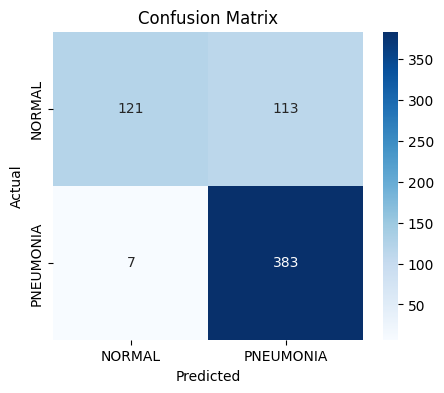

In [16]:
print("evaluating CNN (from scratch):")
evaluate_model(cnn_model, test_loader)


evaluating ResNet18:
              precision    recall  f1-score   support

      NORMAL       0.93      0.49      0.64       234
   PNEUMONIA       0.76      0.98      0.86       390

    accuracy                           0.79       624
   macro avg       0.84      0.73      0.75       624
weighted avg       0.82      0.79      0.77       624



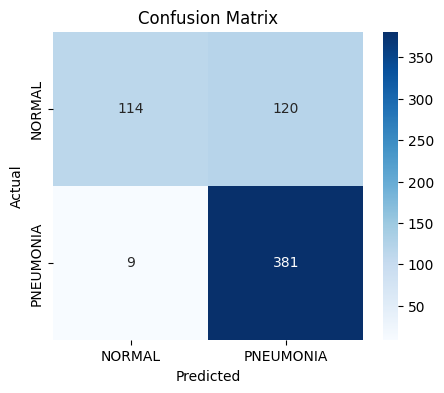

In [17]:
print("evaluating ResNet18:")
evaluate_model(resnet_model, test_loader)


In [18]:
!pip install opencv-python


In [36]:
import sys
sys.modules.pop('cv2', None)  # Remove broken import

!pip install --force-reinstall opencv-python  --quiet

import cv2
print(cv2.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 107.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchcam 0.4.0 requires numpy<2.0.0,>=1.17.2, but you have numpy 2.3.0 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.0 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.0 which is incompatible.
4.11.0


✅ True Label: 0, Predicted: 0


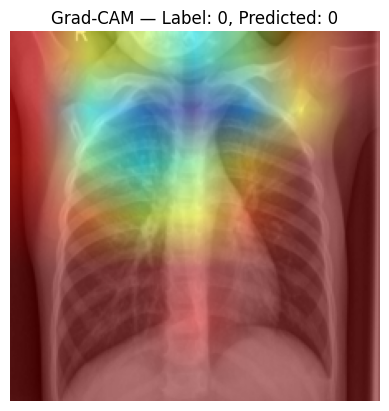

In [41]:

from torchcam.methods import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import cv2

resnet_model.eval()
for param in resnet_model.parameters():
    param.requires_grad = True

cam_extractor = GradCAM(resnet_model, target_layer="layer4")

index = 5  # change this until label == prediction
sample_img, label = test_dataset[index]


input_tensor = sample_img.unsqueeze(0).to(device)


output = resnet_model(input_tensor)
pred_class = output.argmax().item()
print(f"✅ True Label: {label}, Predicted: {pred_class}")

if pred_class == label:

    activation_map = cam_extractor(pred_class, output)[0].cpu().numpy()


    if activation_map.ndim == 3:
        activation_map = activation_map.squeeze()
    activation_map = np.uint8(255 * (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min() + 1e-8))


    heatmap = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)


    img_np = input_tensor.squeeze().permute(1, 2, 0).detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    img_np = np.uint8(255 * img_np)


    heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))

    # Overlay heatmap
    superimposed_img = cv2.addWeighted(heatmap, 0.5, img_np, 0.5, 0)


    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title(f"Grad-CAM — Label: {label}, Predicted: {pred_class}")
    plt.show()

else:
    print(" Prediction incorrect — try another index")
